In [84]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
from typing import TypedDict, Literal 
from pydantic import BaseModel, Field
from langchain_core.messages import HumanMessage, SystemMessage

In [85]:
model = ChatOllama(model='llama3.2:latest')


In [86]:
class AnswerSchema(BaseModel):
    answer: Literal['yes','no'] = Field(description='Anwser of a question in binary, e.g yes or no')


In [87]:
structured_model = model.with_structured_output(AnswerSchema)

In [88]:
class LLMState(TypedDict):
    question: str
    answer: AnswerSchema
    response: str

In [89]:
graph = StateGraph(LLMState)

In [90]:
def answer(state: LLMState):
    question = state['question']

    msgs = [SystemMessage('Answer the following question in yes or no manner, no need to say anything else except yes or no'), HumanMessage(f'Here is the question : {question}')]

    result = structured_model.invoke(msgs).answer 

    return {'answer': result}


def response(state: LLMState):
    question = state['question']
    answer = state['answer']

    msgs = [SystemMessage(content='Elaborate the answer - expalin the reason behind it but keep it short'), HumanMessage(content=f'Here is the question : {question} \n The answer : {answer}')]

    result = model.invoke(msgs).content

    return {'response': result}

def no_response(state: LLMState):
    return {'response': 'No response'}


def router(state: LLMState) -> Literal['response', 'no_response']:
    if state['answer'] == 'yes':
        return 'response'
    else:
        return 'no_response'

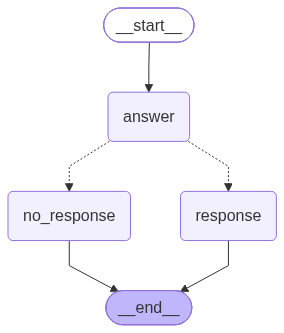

In [91]:
graph.add_node('answer', answer)
# graph.add_node('router', router)
graph.add_node('response', response)
graph.add_node('no_response', no_response)

graph.add_edge(START, 'answer')
graph.add_conditional_edges('answer', router)
graph.add_edge('response', END)
graph.add_edge('no_response', END)

workflow = graph.compile()
workflow

In [92]:
initial_state = {'question' : 'Is sky pink?'}

final_state = workflow.invoke(initial_state)

print(final_state)

{'question': 'Is sky pink?', 'answer': 'no', 'response': 'No response'}
